In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import os
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Path to your file in Drive
file_path = '/content/drive/MyDrive/news.csv'

df = pd.read_csv(file_path)
df.head()


Mounted at /content/drive


,text,label
0,Gere faults Trump for blurring meaning of 'ref...,1
1,German parties start to find common ground in ...,1
2,Senate Democratic leader says Attorney General...,1
3,"Tennis: Kyrgios fined $10,000 for Shanghai wal...",1
4,Trump Threw Mar-A-Lago Fundraiser For Woman A...,0


In [12]:
df = pd.read_csv('/content/drive/MyDrive/news.csv')
df.head()


,text,label
0,Gere faults Trump for blurring meaning of 'ref...,1
1,German parties start to find common ground in ...,1
2,Senate Democratic leader says Attorney General...,1
3,"Tennis: Kyrgios fined $10,000 for Shanghai wal...",1
4,Trump Threw Mar-A-Lago Fundraiser For Woman A...,0


##Observation


In [13]:
print("\n"+ "="*50)
print("Total Records:",df.shape)
print("="*50)

print("\n"+ "="*50)
print("Total Columns:",df.columns)
print("="*50)

print("\n"+ "="*50)
print("information about dataset:",df.info())
print("="*50)

print("\n"+ "="*50)
print("Data Types in dataset:",df.dtypes)
print("="*50)

print("\n"+ "="*50)
print("Missing values identifye:",df.isnull().sum())
print("="*50)



Total Records: (45757, 2)

Total Columns: Index(['text', 'label'], dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45757 entries, 0 to 45756
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    45757 non-null  object
 1   label   45757 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 715.1+ KB
information about dataset: None

Data Types in dataset: text     object
label     int64
dtype: object

Missing values identifye: text     0
label    0
dtype: int64


In [10]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print("="*50)
print("Total Duplicate Rows:", duplicates)
print("="*50)

Total Duplicate Rows: 0


In [14]:
# Unique Lables
print("="*50)
print("Unique Lables:",df["label"].unique())
print("="*50)

Unique Lables: [1 0]


In [15]:
# Label Counts
print("="*50)
print("Lables Counts:",df["label"].value_counts())
print("="*50)

Lables Counts: label
1    22900
0    22857
Name: count, dtype: int64


In [16]:
# Label Percentage
print("="*50)
print("Labels Precentages")
print(df["label"].value_counts(normalize=True)*100)
print("="*50)

Labels Precentages
label
1    50.046987
0    49.953013
Name: proportion, dtype: float64


In [18]:
# Label 0 ke 5 News
print("="*50)
print("Label 0 News")
print(df[df['label']==0].head())
print("="*50)


Label 0 News
                                                 text  label
4    Trump Threw Mar-A-Lago Fundraiser For Woman A...      0
5    President Curtsy Delivers A Really Sick Burn ...      0
7    Trump Completely COLLAPSING In Most Important...      0
9   BOOM! Hey Democrats….Why The Violent Riots? YO...      0
10  WHOA! MICHAEL MOORE Says TRUMP Is Only Hope To...      0


In [14]:
# Label 1 ke 5 News
print("="*50)
print("Label 1 News")
print(df[df['label']==1].head())
print("="*50)

Label 1 News
                                                text  label
0  Gere faults Trump for blurring meaning of 'ref...      1
1  German parties start to find common ground in ...      1
2  Senate Democratic leader says Attorney General...      1
3  Tennis: Kyrgios fined $10,000 for Shanghai wal...      1
6  NSA risks talent exodus amid morale slump, Tru...      1


In [15]:
import string

def remove_punctuation(text):

    for p in string.punctuation:
        text = text.replace(p, "")

    return text

In [16]:
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

In [21]:
# nltk.download("punkt")
# nltk.download("stopwords")


nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [18]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

In [19]:
def clean_text(text):

    # 1. Lowercase
    text = text.lower()

    # 2. Remove Punctuation
    for p in string.punctuation:
        text = text.replace(p, "")

    # 3. Tokenization
    words = word_tokenize(text)

    # 4. Remove Stopwords
    words = [word for word in words if word not in stop_words]

    # 5. Stemming
    words = [stemmer.stem(word) for word in words]

    # 6. Join Again
    return " ".join(words)

In [22]:
df["cleaned_text"] = df["text"].apply(clean_text)


In [23]:
df[["text", "cleaned_text"]].head()

,text,cleaned_text
0,Gere faults Trump for blurring meaning of 'ref...,gere fault trump blur mean refuge terrorist be...
1,German parties start to find common ground in ...,german parti start find common ground coalit t...
2,Senate Democratic leader says Attorney General...,senat democrat leader say attorney gener sessi...
3,"Tennis: Kyrgios fined $10,000 for Shanghai wal...",tenni kyrgio fine 10000 shanghai walk tenni ch...
4,Trump Threw Mar-A-Lago Fundraiser For Woman A...,trump threw maralago fundrais woman center bri...


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF Object
tfidf = TfidfVectorizer()

# Convert Clean Text into Numerical Features
X = tfidf.fit_transform(df["cleaned_text"])

# Target Variable
y = df["label"]

# Check Shape
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (45757, 232092)
Shape of y: (45757,)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (36605, 232092)
X_test Shape  : (9152, 232092)
y_train Shape : (36605,)
y_test Shape  : (9152,)


In [29]:
from sklearn.linear_model import LogisticRegression

# Create Model
model = LogisticRegression(max_iter=1000)

# Train Model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [31]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9701704545454546


In [32]:
precision = precision_score(y_test, y_pred)

print("Precision :", precision)

Precision : 0.9717415115005477


In [33]:
recall = recall_score(y_test, y_pred)

print("Recall :", recall)

Recall : 0.9685589519650655


In [34]:
f1 = f1_score(y_test, y_pred)

print("F1 Score :", f1)

F1 Score : 0.9701476216511755


In [35]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4443  129]
 [ 144 4436]]


In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      4572
           1       0.97      0.97      0.97      4580

    accuracy                           0.97      9152
   macro avg       0.97      0.97      0.97      9152
weighted avg       0.97      0.97      0.97      9152



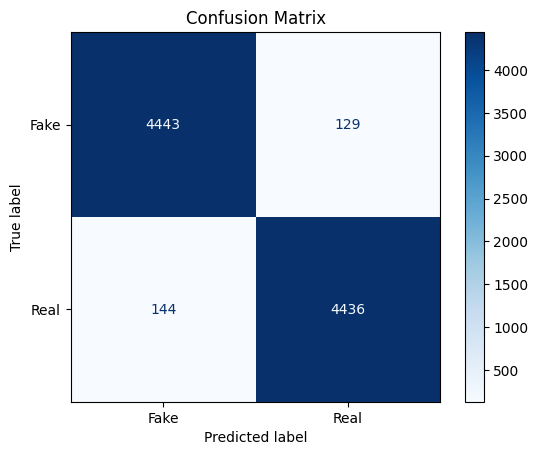

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Fake", "Real"])

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [39]:
import pickle
with open("fake_news_model.pkl", "wb") as file:
    pickle.dump(model, file)

In [40]:
with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

In [41]:

print("✅ Model Saved Successfully!")
print("✅ TF-IDF Vectorizer Saved Successfully!")

✅ Model Saved Successfully!
✅ TF-IDF Vectorizer Saved Successfully!


In [42]:
import os

print(os.listdir())

['.config', 'tfidf_vectorizer.pkl', 'fake_news_model.pkl', 'drive', 'sample_data']
